Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import pickle
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

Load the Dataset

In [ ]:
DATA_PATH = "/content/sample_data/fertilizer_dataset.csv"
data = pd.read_csv(DATA_PATH)
print("✅ Dataset Loaded Successfully!")
print("Shape of dataset:", data.shape)
display(data.head())

✅ Dataset Loaded Successfully!
Shape of dataset: (4800, 8)


,Crop,Growth_Stage,Soil_Type,N,P,K,pH,Recommended_Fertilizer
0,Brinjal,Fruiting,Black Soil,46.0,26.3,65.6,6.53,Cow Manure Compost
1,Brinjal,Fruiting,Sandy Loam,49.8,28.4,83.2,6.33,Vermicompost
2,Brinjal,Flowering,Black Soil,52.2,49.3,38.5,7.15,Bone Meal
3,Brinjal,Flowering,Reddish Soil,51.5,47.0,39.3,6.67,Seaweed Extract
4,Brinjal,Seedling,Reddish Soil,32.8,16.8,10.8,6.78,Jeevamrut


Encode Categorical Columns

In [ ]:
crop_encoder = LabelEncoder()
stage_encoder = LabelEncoder()
soil_encoder = LabelEncoder()
fert_encoder = LabelEncoder()

data["Crop"] = crop_encoder.fit_transform(data["Crop"])
data["Growth_Stage"] = stage_encoder.fit_transform(data["Growth_Stage"])
data["Soil_Type"] = soil_encoder.fit_transform(data["Soil_Type"])
data["Recommended_Fertilizer"] = fert_encoder.fit_transform(data["Recommended_Fertilizer"])

Create Encoding Dictionaries

In [ ]:
fert_dict = {i: fert_encoder.inverse_transform([i])[0] for i in range(len(fert_encoder.classes_))}
crop_dict = {i: crop_encoder.inverse_transform([i])[0] for i in range(len(crop_encoder.classes_))}
stage_dict = {i: stage_encoder.inverse_transform([i])[0] for i in range(len(stage_encoder.classes_))}
soil_dict = {i: soil_encoder.inverse_transform([i])[0] for i in range(len(soil_encoder.classes_))}

# Reverse mappings for user input
crop_rev = {v: k for k, v in crop_dict.items()}
stage_rev = {v: k for k, v in stage_dict.items()}
soil_rev = {v: k for k, v in soil_dict.items()}

Feature and Target Selection

In [ ]:
X = data.drop("Recommended_Fertilizer", axis=1)
y = data["Recommended_Fertilizer"]

print("\n📊 Original Class Distribution:", Counter(y))


📊 Original Class Distribution: Counter({16: 901, 19: 513, 12: 438, 2: 430, 14: 292, 4: 280, 9: 255, 0: 239, 21: 236, 6: 235, 10: 148, 23: 147, 1: 142, 20: 105, 7: 103, 5: 76, 8: 76, 17: 54, 13: 48, 15: 24, 22: 19, 11: 19, 18: 12, 3: 8})


Balance Data Using SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print("✅ Class Distribution After SMOTE:", Counter(y_res))

✅ Class Distribution After SMOTE: Counter({2: 901, 16: 901, 0: 901, 12: 901, 6: 901, 5: 901, 10: 901, 19: 901, 14: 901, 4: 901, 9: 901, 23: 901, 1: 901, 20: 901, 13: 901, 21: 901, 7: 901, 8: 901, 17: 901, 22: 901, 15: 901, 18: 901, 3: 901, 11: 901})


Dataset Splitting (70-20-10)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X_res, y_res, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=42)

print("\n📈 Dataset Split:")
print(f"Training Samples: {len(X_train)}")
print(f"Validation Samples: {len(X_val)}")
print(f"Testing Samples: {len(X_test)}")


📈 Dataset Split:
Training Samples: 15136
Validation Samples: 4325
Testing Samples: 2163


Model Definition (XGBoost)

In [ ]:
xgb_pipeline = make_pipeline(
    XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        learning_rate=0.1,
        n_estimators=150,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8
    )
)

Model Training

In [ ]:
xgb_pipeline.fit(X_train, y_train)
print("\n✅ Model Training Completed Successfully!")


✅ Model Training Completed Successfully!


Model Evaluation

In [ ]:
y_pred_train = xgb_pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)

# --- Validation Accuracy ---
y_pred_val = xgb_pipeline.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred_val)

# --- Test Accuracy ---
y_pred_test = xgb_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\n📊 Training Accuracy: {train_accuracy*100:.2f}%")
print(f"📊 Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"📊 Test Accuracy: {test_accuracy*100:.2f}%")


📊 Training Accuracy: 93.63%
📊 Validation Accuracy: 78.82%
📊 Test Accuracy: 77.72%


Detailed Evaluation Metrics

In [ ]:
print("\n🔍 Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=list(fert_encoder.classes_)))


🔍 Classification Report (Test Set):
                                                                    precision    recall  f1-score   support

                                                         Bone Meal       0.59      0.69      0.63        80
                Bone Meal + NPK 19-19-19 (Water-Soluble) (diluted)       0.71      0.95      0.81        93
                                                Cow Manure Compost       0.64      0.48      0.55        89
                             Cow Manure Compost + MOP (small dose)       1.00      0.99      0.99        87
       Cow Manure Compost + NPK 19-19-19 (Water-Soluble) (diluted)       0.74      0.50      0.60       102
                    Cow Manure Compost + Urea (46% N) (small dose)       0.91      0.86      0.88       104
                                                         Jeevamrut       0.63      0.87      0.73        89
                Jeevamrut + NPK 19-19-19 (Water-Soluble) (diluted)       0.69      0.97      0.80 

Confusion Matrix Visualization

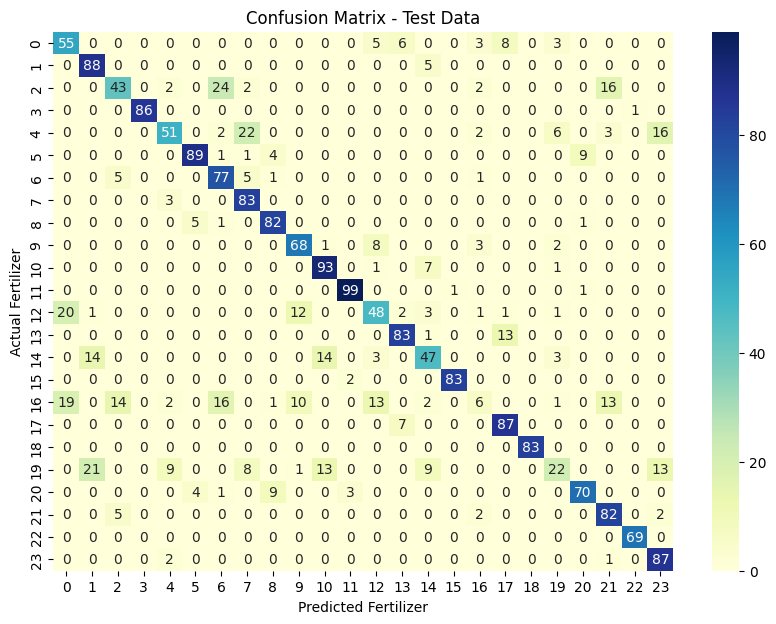

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix - Test Data")
plt.xlabel("Predicted Fertilizer")
plt.ylabel("Actual Fertilizer")
plt.show()

Model Performance Visualization

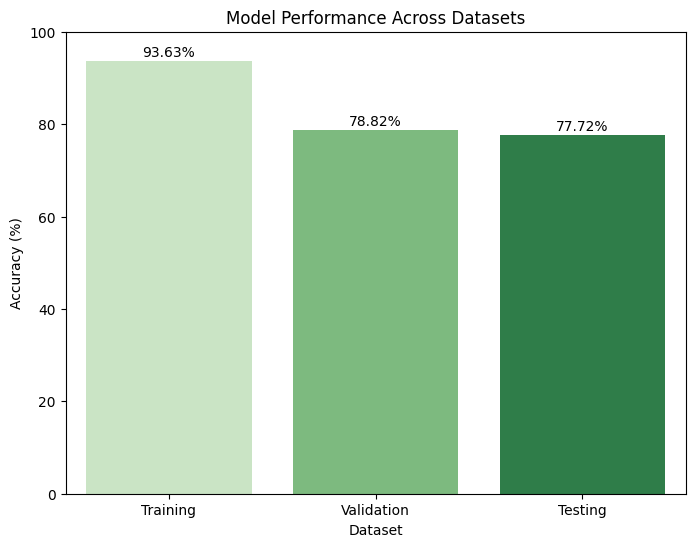

In [ ]:
performance_data = {
    'Dataset': ['Training', 'Validation', 'Testing'],
    'Accuracy (%)': [train_accuracy*100, val_accuracy*100, test_accuracy*100]
}
perf_df = pd.DataFrame(performance_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Dataset', y='Accuracy (%)', data=perf_df, palette="Greens")
plt.title("Model Performance Across Datasets")
plt.ylim(0, 100)
for i, acc in enumerate(perf_df['Accuracy (%)']):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha='center')
plt.show()

Sample Predictions

In [ ]:
X_test_df = pd.DataFrame(X_test, columns=["Crop", "Growth_Stage", "Soil_Type", "N", "P", "K", "pH"])
X_test_df["Crop"] = X_test_df["Crop"].apply(lambda x: crop_dict[int(x)])
X_test_df["Growth_Stage"] = X_test_df["Growth_Stage"].apply(lambda x: stage_dict[int(x)])
X_test_df["Soil_Type"] = X_test_df["Soil_Type"].apply(lambda x: soil_dict[int(x)])
X_test_df["Actual_Fertilizer"] = [fert_dict[i] for i in y_test]
X_test_df["Predicted_Fertilizer"] = [fert_dict[i] for i in y_pred_test]

print("\n📋 Sample Predictions (First 10 Rows):")
display(X_test_df.head(10))


📋 Sample Predictions (First 10 Rows):


,Crop,Growth_Stage,Soil_Type,N,P,K,pH,Actual_Fertilizer,Predicted_Fertilizer
10746,Tomato,Seedling,Black Soil,16.807916,11.400000,19.284168,6.772505,Jeevamrut + Urea (46% N) (small dose),Jeevamrut + Urea (46% N) (small dose)
7839,Cucumber,Fruiting,Reddish Soil,45.653322,38.023163,90.483304,6.297325,Cow Manure Compost + NPK 19-19-19 (Water-Solub...,Cow Manure Compost + NPK 19-19-19 (Water-Solub...
16572,Coriander,Flowering,Reddish Soil,48.298793,16.353568,17.939297,6.373304,Vermicompost + Bone Meal,Vermicompost + Bone Meal
17010,Cucumber,Flowering,Black Soil,58.905641,26.970663,58.082651,6.714499,Vermicompost + Bone Meal,Vermicompost + Bone Meal
6646,Coriander,Seedling,Reddish Soil,23.760109,8.860025,8.500126,7.114031,Cow Manure Compost,Jeevamrut
12430,Cucumber,Vegetative,Reddish Soil,77.308858,33.700640,39.609498,6.726457,Neem Cake + NPK 19-19-19 (Water-Soluble) (dilu...,Neem Cake + NPK 19-19-19 (Water-Soluble) (dilu...
12124,Coriander,Vegetative,Reddish Soil,33.357677,23.343096,20.971613,6.452710,Neem Cake + NPK 19-19-19 (Water-Soluble) (dilu...,Neem Cake + NPK 19-19-19 (Water-Soluble) (dilu...
8470,Cucumber,Seedling,Black Soil,16.592192,10.758057,11.603404,6.846877,Cow Manure Compost + Urea (46% N) (small dose),Vermicompost + Urea (46% N) (small dose)
8477,Brinjal,Seedling,Reddish Soil,20.435562,15.864723,17.870555,6.835932,Cow Manure Compost + Urea (46% N) (small dose),Cow Manure Compost + Urea (46% N) (small dose)
16689,Cucumber,Flowering,Reddish Soil,48.678822,26.116234,44.667531,6.340894,Vermicompost + Bone Meal,Vermicompost + Bone Meal


Interactive Recommendation System

In [ ]:
crop_widget = widgets.Dropdown(options=list(crop_rev.keys()), description='Crop:')
stage_widget = widgets.Dropdown(options=list(stage_rev.keys()), description='Stage:')
soil_widget = widgets.Dropdown(options=list(soil_rev.keys()), description='Soil Type:')
N_input = widgets.FloatText(value=200, description='N:')
P_input = widgets.FloatText(value=100, description='P:')
K_input = widgets.FloatText(value=150, description='K:')
pH_input = widgets.FloatText(value=6.5, description='pH:')

predict_button = widgets.Button(description="Recommend Fertilizer", button_style='success')
output = widgets.Output()

def on_predict_button_clicked(b):
    with output:
        clear_output()
        crop_encoded = crop_rev[crop_widget.value]
        stage_encoded = stage_rev[stage_widget.value]
        soil_encoded = soil_rev[soil_widget.value]

        user_data = np.array([[crop_encoded, stage_encoded, soil_encoded,
                               N_input.value, P_input.value, K_input.value, pH_input.value]])

        fert_pred_encoded = xgb_pipeline.predict(user_data)[0]
        fert_pred = fert_dict[fert_pred_encoded]

        print(f"🌿 Recommended Fertilizer: {fert_pred}")

predict_button.on_click(on_predict_button_clicked)
display(crop_widget, stage_widget, soil_widget, N_input, P_input, K_input, pH_input, predict_button, output)

Dropdown(description='Crop:', options=('Brinjal', 'Coriander', 'Cucumber', 'Tomato'), value='Brinjal')

Dropdown(description='Stage:', options=('Flowering', 'Fruiting', 'Seedling', 'Vegetative'), value='Flowering')

Dropdown(description='Soil Type:', options=('Black Soil', 'Reddish Soil', 'Sandy Loam'), value='Black Soil')

FloatText(value=200.0, description='N:')

FloatText(value=100.0, description='P:')

FloatText(value=150.0, description='K:')

FloatText(value=6.5, description='pH:')

Button(button_style='success', description='Recommend Fertilizer', style=ButtonStyle())

Output()

Save Trained Model

In [ ]:
model_filename = "fertilizer_model.pkl"
with open(model_filename, "wb") as file:
    pickle.dump(xgb_pipeline, file)

print(f"\n💾 Trained Model Saved as {model_filename}")


💾 Trained Model Saved as fertilizer_model.pkl


In [ ]:
import pickle
pickle.dump(crop_encoder, open("crop_encoder.pkl", "wb"))
pickle.dump(stage_encoder, open("stage_encoder.pkl", "wb"))
pickle.dump(soil_encoder, open("soil_encoder.pkl", "wb"))
pickle.dump(fert_encoder, open("fert_encoder.pkl", "wb"))


In [ ]:
import joblib

joblib.dump(fert_dict, "fert_dict.pkl")  # save the dict

['fert_dict.pkl']